# Zone J Worst-Case 24h Screening

This notebook ranks stressed hourly windows from the `baseline_after_retire` full-year run and recommends a first 24-hour contingency window for zone J.

Default setup:
- baseline: `baseline_after_retire`
- zone: `J`
- first contingency: largest surviving zone-J thermal (`Ravenswood ST 02`)
- window length: 24 hours

Important modeling note: this is a screening workflow. It does **not** yet create a zone-J-only load-shedding variable inside Sienna; it only identifies the baseline hours where a zone-J thermal outage is most likely to be difficult to recover from.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "zone_j_worst_24h.py").exists():
    NOTEBOOK_DIR = Path("/home/fs01/jl2966/nygrid2sienna_baseline_after_retire/analysis")

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import zone_j_worst_24h as zj

pd.options.display.float_format = "{:,.3f}".format
plt.style.use("seaborn-v0_8-whitegrid")

BASE_DIR = NOTEBOOK_DIR.parent
ZONE = "J"
WINDOW_HOURS = 24

context = zj.get_zone_context(BASE_DIR, zone=ZONE)
TARGET_UNIT = context["biggest_zone_thermal"]

print(f"Repo root: {BASE_DIR}")
print(f"Zone: {ZONE}")
print(f"First contingency unit: {TARGET_UNIT} ({context['biggest_zone_thermal_pmax_mw']:,.0f} MW)")
print("Tip: change WINDOW_HOURS to 8 and rerun if you want an 8-hour screen.")


Repo root: /home/fs01/jl2966/nygrid2sienna_baseline_after_retire
Zone: J
First contingency unit: Ravenswood ST 02 (1,000 MW)
Tip: change WINDOW_HOURS to 8 and rerun if you want an 8-hour screen.


In [2]:
context_summary = pd.DataFrame(
    [
        {"metric": "zone_buses", "value": ", ".join(str(v) for v in context["zone_bus_ids"])},
        {"metric": "zone_thermal_count", "value": len(context["zone_thermal_names"])},
        {"metric": "zone_thermal_pmax_mw", "value": context["zone_thermal_pmax_mw"]},
        {"metric": "zone_storage_energy_cap_mwh", "value": context["zone_storage_energy_cap_mwh"]},
        {"metric": "direct_zone_hvdc", "value": ", ".join(context["direct_zone_hvdc_names"])},
        {"metric": "if10_limit_mw", "value": context["if10_limit_mw"]},
        {"metric": "if11_limit_mw", "value": context["if11_limit_mw"]},
    ]
)
display(context_summary)

score_weights = pd.DataFrame(
    [{"metric": metric, "weight": weight} for metric, weight in zj.DEFAULT_SCORE_WEIGHTS.items()]
)
display(score_weights)


,metric,value
0,zone_buses,"81, 82"
1,zone_thermal_count,52
2,zone_thermal_pmax_mw,"8,427.700"
3,zone_storage_energy_cap_mwh,"34,096.000"
4,direct_zone_hvdc,"HTP, VFT"
5,if10_limit_mw,"4,350.000"
6,if11_limit_mw,"1,293.000"


,metric,weight
0,zone_j_load_mw,1.250
1,contingency_unit_loading,1.500
2,if10_utilization,1.000
3,zone_j_hvdc_abs_utilization,0.750
4,zone_j_storage_discharge_mw,0.500
5,zone_j_storage_soc_frac,-0.750
6,zone_j_thermal_headroom_mw,-1.000


In [3]:
hourly = zj.build_hourly_metrics(BASE_DIR, zone=ZONE, contingency_unit=TARGET_UNIT)
windows = zj.rank_windows(hourly, window_hours=WINDOW_HOURS)

recommended = windows.iloc[0]
recommended_start = recommended["window_start"]
recommended_end = recommended["window_end"]

display(
    windows.head(10)[
        [
            "window_start",
            "window_end",
            "window_score",
            "mean_zone_j_load_mw",
            "max_zone_j_load_mw",
            "mean_contingency_unit_dispatch_mw",
            "max_contingency_unit_dispatch_mw",
            "mean_if10_utilization",
            "mean_zone_j_hvdc_abs_utilization",
            "min_zone_j_storage_soc_frac",
            "min_zone_j_thermal_headroom_mw",
        ]
    ]
)

print(f"Recommended {WINDOW_HOURS}h window: {recommended_start} to {recommended_end}")


,window_start,window_end,window_score,mean_zone_j_load_mw,max_zone_j_load_mw,mean_contingency_unit_dispatch_mw,max_contingency_unit_dispatch_mw,mean_if10_utilization,mean_zone_j_hvdc_abs_utilization,min_zone_j_storage_soc_frac,min_zone_j_thermal_headroom_mw
0,2019-02-01 06:00:00,2019-02-02 05:00:00,671.104,"13,753.051","16,354.559",240.420,"1,000.000",0.844,1.000,0.100,763.000
1,2019-02-01 07:00:00,2019-02-02 06:00:00,671.087,"13,649.771","16,354.559",240.420,"1,000.000",0.850,1.000,0.100,763.000
2,2019-02-01 08:00:00,2019-02-02 07:00:00,621.841,"13,526.324","16,272.052",209.797,"1,000.000",0.864,1.000,0.100,763.000
3,2019-02-01 00:00:00,2019-02-01 23:00:00,606.654,"14,161.717","16,354.559",198.886,"1,000.000",0.858,1.000,0.100,763.000
4,2019-02-01 01:00:00,2019-02-02 00:00:00,606.066,"14,102.337","16,354.559",198.886,"1,000.000",0.859,1.000,0.100,763.000
5,2019-02-01 02:00:00,2019-02-02 01:00:00,605.491,"14,040.932","16,354.559",198.886,"1,000.000",0.856,1.000,0.100,763.000
6,2019-02-01 03:00:00,2019-02-02 02:00:00,605.183,"13,975.758","16,354.559",198.886,"1,000.000",0.855,1.000,0.100,763.000
7,2019-02-01 05:00:00,2019-02-02 04:00:00,605.076,"13,836.223","16,354.559",198.886,"1,000.000",0.843,1.000,0.100,763.000
8,2019-02-01 04:00:00,2019-02-02 03:00:00,604.401,"13,908.923","16,354.559",198.886,"1,000.000",0.846,1.000,0.100,763.000
9,2019-01-31 23:00:00,2019-02-01 22:00:00,604.274,"14,263.497","16,354.559",198.886,"1,000.000",0.845,1.000,0.100,763.000


Recommended 24h window: 2019-02-01 06:00:00 to 2019-02-02 05:00:00


In [4]:
window_hourly = zj.window_slice(hourly, recommended_start, recommended_end)

display(
    window_hourly.sort_values("stress_score", ascending=False)
    [[
        "zone_j_load_mw",
        "contingency_unit_dispatch_mw",
        "largest_online_zone_j_unit_name",
        "largest_online_zone_j_unit_dispatch_mw",
        "if10_flow_mw",
        "if10_utilization",
        "zone_j_hvdc_abs_mw",
        "zone_j_storage_discharge_mw",
        "zone_j_storage_soc_frac",
        "zone_j_thermal_headroom_mw",
        "system_clean_dispatch_mw",
        "stress_score",
    ]]
    .head(12)
)


,zone_j_load_mw,contingency_unit_dispatch_mw,largest_online_zone_j_unit_name,largest_online_zone_j_unit_dispatch_mw,if10_flow_mw,if10_utilization,zone_j_hvdc_abs_mw,zone_j_storage_discharge_mw,zone_j_storage_soc_frac,zone_j_thermal_headroom_mw,system_clean_dispatch_mw,stress_score
DateTime,,,,,,,,,,,,
2019-02-01 08:00:00,"16,272.052","1,000.000",Ravenswood ST 02,"1,000.000","3,151.673",0.725,"1,320.000","2,554.133",0.400,763.000,"20,887.907",80.217
2019-02-01 16:00:00,"13,660.993","1,000.000",Ravenswood ST 02,"1,000.000","3,851.874",0.885,"1,320.000",109.276,0.243,763.000,"11,720.935",78.291
2019-02-02 05:00:00,"12,427.422",999.828,Ravenswood ST 02,999.828,"2,837.695",0.652,"1,320.000",0.000,0.171,763.172,"9,970.034",76.822
2019-02-01 07:00:00,"16,354.559",737.955,Astoria 5,776.000,"2,516.778",0.579,"1,320.000","2,813.000",0.475,"1,025.045","12,920.979",62.321
2019-02-01 10:00:00,"15,192.547",659.797,Astoria 5,776.000,"4,350.000",1.000,"1,320.000","1,449.000",0.283,"1,103.203","31,690.140",57.703
2019-02-01 17:00:00,"14,293.311",675.718,Astoria 5,776.000,"3,752.206",0.863,"1,320.000",945.584,0.215,"1,087.282","7,677.786",57.646
2019-02-01 12:00:00,"13,985.338",525.958,Astoria 5,776.000,"4,350.000",1.000,"1,320.000",0.000,0.246,"1,237.042","35,748.752",47.434
2019-02-01 21:00:00,"13,786.489",122.832,Astoria 5,776.000,"3,631.425",0.835,"1,320.000",0.000,0.100,"1,640.168","11,893.051",20.474
2019-02-01 09:00:00,"15,769.012",3.000,Astoria 5,776.000,"4,350.000",1.000,"1,320.000","2,531.988",0.325,"1,760.000","27,446.274",14.981


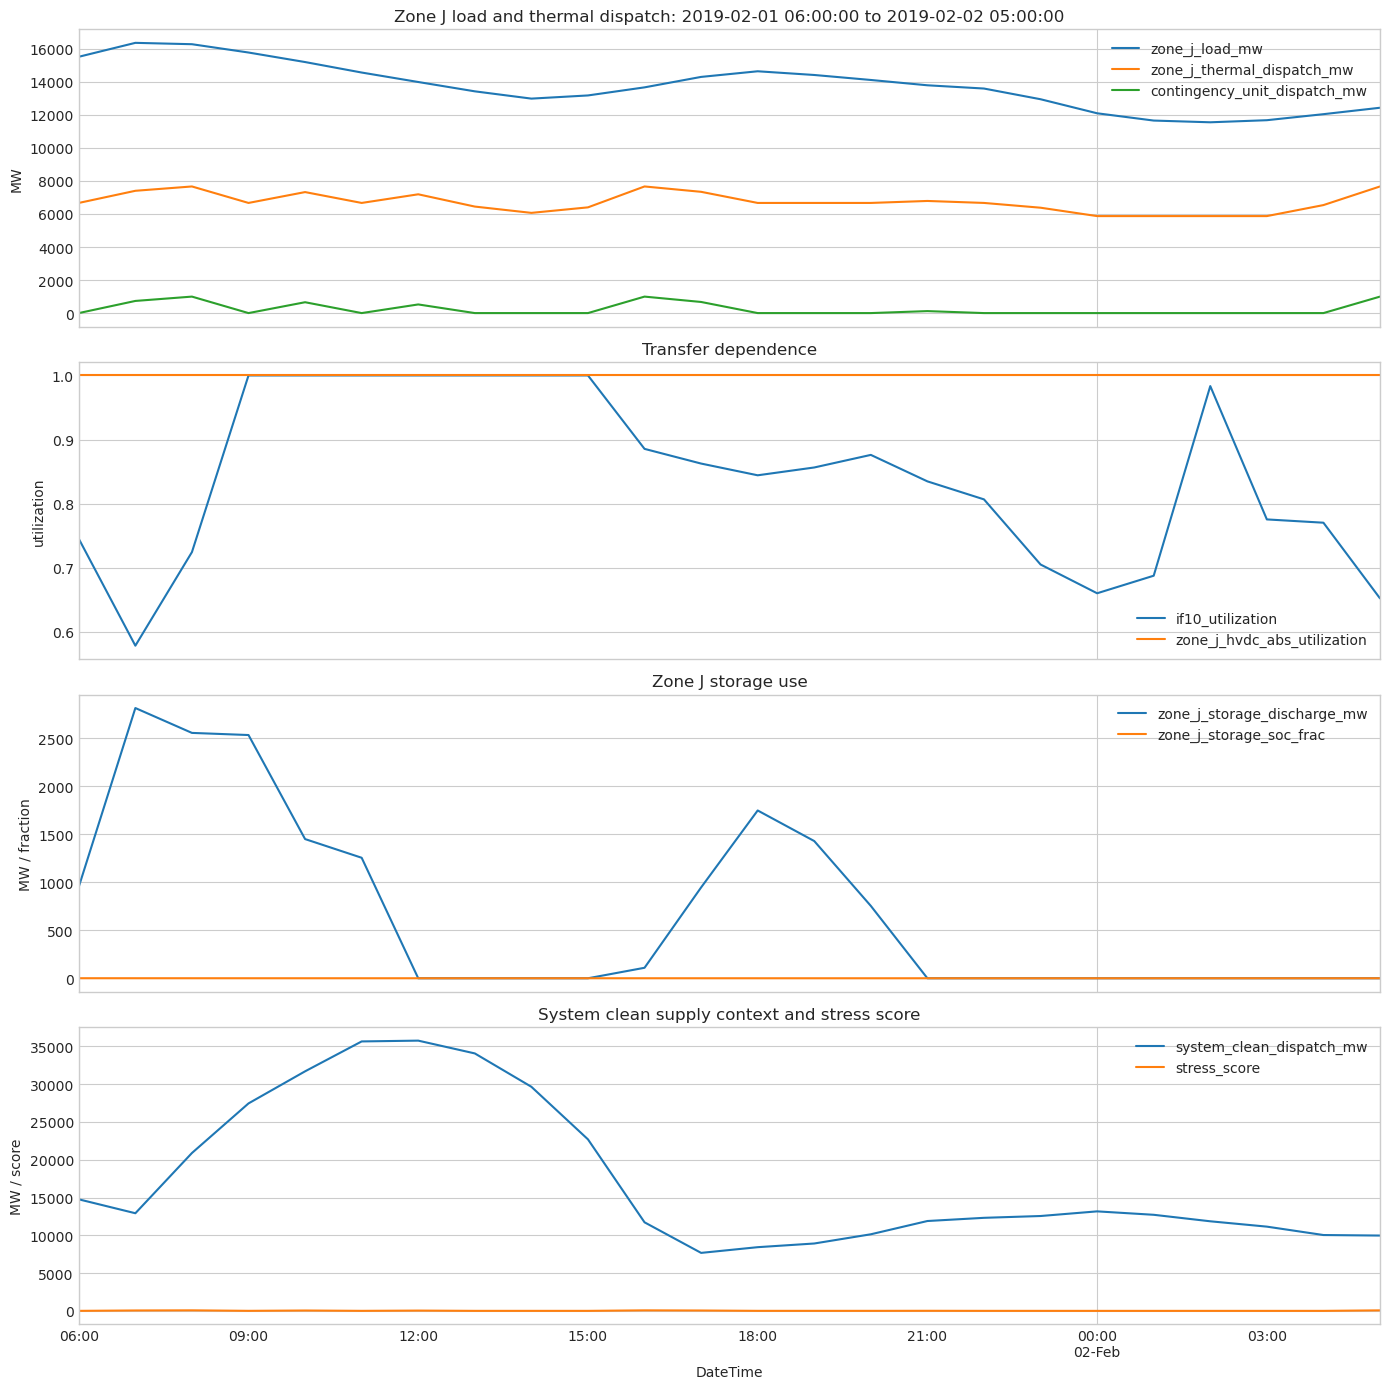

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

window_hourly[["zone_j_load_mw", "zone_j_thermal_dispatch_mw", "contingency_unit_dispatch_mw"]].plot(ax=axes[0])
axes[0].set_title(f"Zone J load and thermal dispatch: {recommended_start} to {recommended_end}")
axes[0].set_ylabel("MW")

window_hourly[["if10_utilization", "zone_j_hvdc_abs_utilization"]].plot(ax=axes[1])
axes[1].set_title("Transfer dependence")
axes[1].set_ylabel("utilization")

window_hourly[["zone_j_storage_discharge_mw", "zone_j_storage_soc_frac"]].plot(ax=axes[2])
axes[2].set_title("Zone J storage use")
axes[2].set_ylabel("MW / fraction")

window_hourly[["system_clean_dispatch_mw", "stress_score"]].plot(ax=axes[3])
axes[3].set_title("System clean supply context and stress score")
axes[3].set_ylabel("MW / score")
axes[3].set_xlabel("DateTime")

plt.tight_layout()


In [6]:
meteorology_window, meteorology_summary = zj.summarize_meteorology_window(
    BASE_DIR,
    recommended_start,
    recommended_end,
    hourly_metrics=hourly,
)

display(meteorology_summary)
print("Interpretation note: this is inferred from the modeled wind/PV resource multipliers and renewable dispatch, not from direct temperature or weather-station data.")
print(zj.describe_meteorology_window(meteorology_summary))


/home/fs01/jl2966/nygrid2sienna_baseline_after_retire/analysis/zone_j_worst_24h.py:96: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  profile.index = pd.date_range("{}-01-01 00:00:00".format(load_year), periods=len(profile), freq="H")
/home/fs01/jl2966/nygrid2sienna_baseline_after_retire/analysis/zone_j_worst_24h.py:96: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  profile.index = pd.date_range("{}-01-01 00:00:00".format(load_year), periods=len(profile), freq="H")
/home/fs01/jl2966/nygrid2sienna_baseline_after_retire/analysis/zone_j_worst_24h.py:96: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  profile.index = pd.date_range("{}-01-01 00:00:00".format(load_year), periods=len(profile), freq="H")


,metric,window_mean,annual_mean,window_mean_percentile,window_min,window_max
0,wind_resource_multiplier,0.209,0.413,30.685,0.090,0.398
1,upv_resource_multiplier,0.122,0.132,64.635,0.000,0.464
2,dpv_resource_multiplier,0.103,0.136,62.626,0.000,0.366
3,total_variable_renewable_output_mw,"13,148.915","18,382.206",40.205,"3,408.086","31,479.052"
4,hydro_dispatch_mw,"4,269.700","1,749.480",100.000,"4,269.700","4,269.700"
5,total_clean_dispatch_mw,"17,418.615","20,131.686",47.135,"7,677.786","35,748.752"
6,zone_j_load_mw,"13,753.051","7,486.106",99.212,"11,547.513","16,354.559"


Interpretation note: this is inferred from the modeled wind/PV resource multipliers and renewable dispatch, not from direct temperature or weather-station data.
Inferred meteorology proxy: winter conditions. Wind availability is below-average (percentile 30.7), utility PV is above-average (percentile 64.6), DPV is above-average (percentile 62.6), and total clean dispatch is around-average (percentile 47.1). Zone-J load is very high for the year (percentile 99.2). This looks more like an extreme-load / tight-transfer window than a system-wide renewable drought.


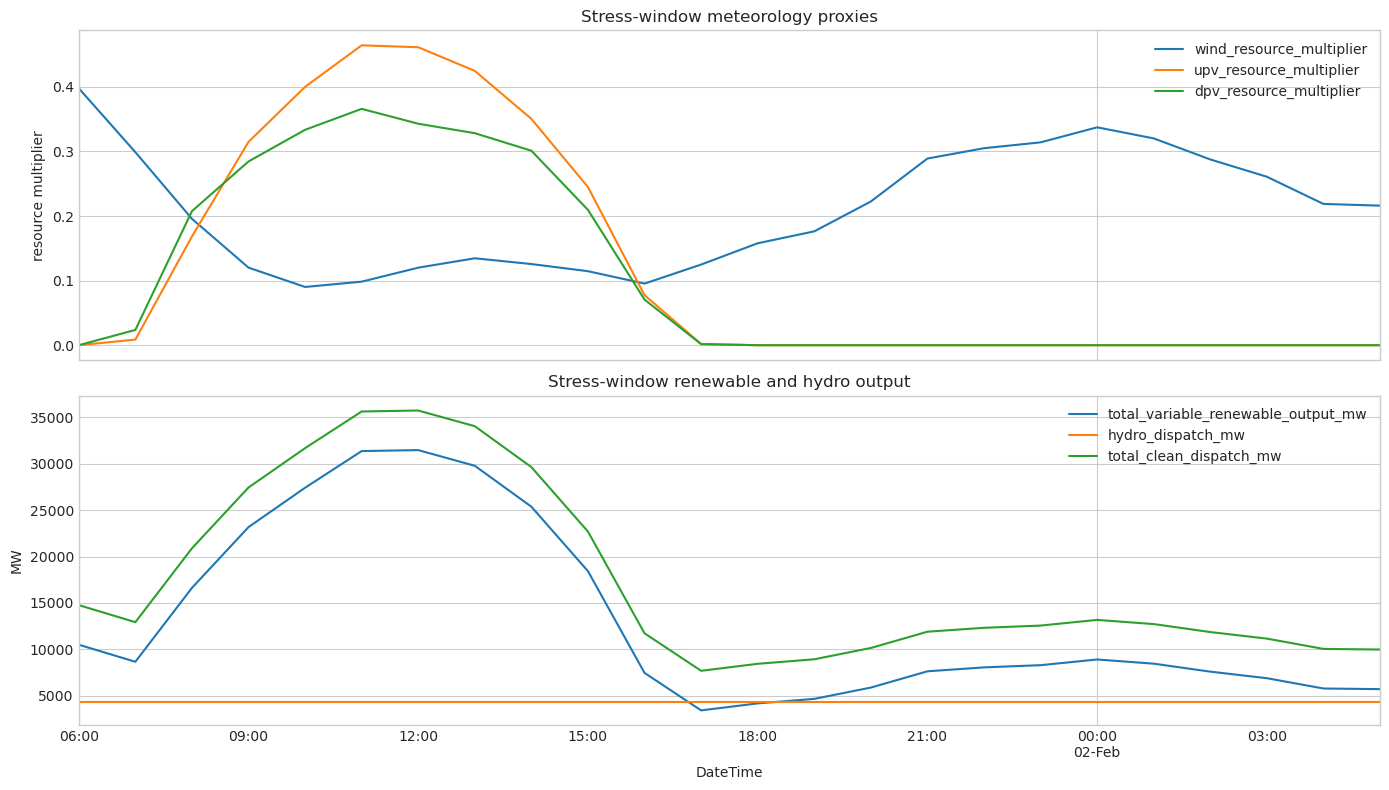

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

meteorology_window[["wind_resource_multiplier", "upv_resource_multiplier", "dpv_resource_multiplier"]].plot(ax=axes[0])
axes[0].set_title("Stress-window meteorology proxies")
axes[0].set_ylabel("resource multiplier")

meteorology_window[["total_variable_renewable_output_mw", "hydro_dispatch_mw", "total_clean_dispatch_mw"]].plot(ax=axes[1])
axes[1].set_title("Stress-window renewable and hydro output")
axes[1].set_ylabel("MW")
axes[1].set_xlabel("DateTime")

plt.tight_layout()


In [8]:
nonthermal = zj.rank_nonthermal_candidates(BASE_DIR, recommended_start, recommended_end, zone=ZONE)

display(
    nonthermal[[
        "name",
        "asset_type",
        "capacity_mw",
        "mean_flow_mw",
        "mean_abs_flow_mw",
        "peak_abs_flow_mw",
        "mean_abs_utilization",
        "peak_abs_utilization",
    ]]
)

print("Interpretation: the first row is the strongest non-thermal second-contingency candidate within the recommended 24h window.")


,name,asset_type,capacity_mw,mean_flow_mw,mean_abs_flow_mw,peak_abs_flow_mw,mean_abs_utilization,peak_abs_utilization
0,HTP,hvdc,660.000,660.000,660.000,660.000,1.000,1.000
1,VFT,hvdc,660.000,660.000,660.000,660.000,1.000,1.000
2,IF_10,interface,"4,350.000","3,670.223","3,670.223","4,350.000",0.844,1.000
3,IF_11,interface,"1,293.000",-515.000,515.000,515.000,0.398,0.398


Interpretation: the first row is the strongest non-thermal second-contingency candidate within the recommended 24h window.
